In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

In [2]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

In [ ]:
Dataraw.close()

In [20]:
save_dir = "Data/CW_Data/AttenuateCW/WeakCoherentSNSPDMeas_v5"
filename='WeakCW_hwp_4_30_70_0_1_0.02_60_take1'
Dataraw = np.load(os.path.join(save_dir, f"{filename}.npz"))
RAW_BASE = os.path.join(save_dir, filename + "_RawTags")
#Dataraw = np.load('Data/CW_Data/AttenuateCW/WeakCoherentSNSPDMeas_v2/'+ Filename +'.npz')
distArr_ideal=Dataraw['distArr_ideal']
distArr_measured=Dataraw['distArr_measured']
mindist=Dataraw['mindist']
maxdist=Dataraw['maxdist']
distSpacing=Dataraw['distSpacing']

# Time/measurement metadata
channels=Dataraw['channels']
num_measurements=Dataraw['num_measurements']
bin_duration_s=Dataraw['bin_duration_s']
CountTime_s=Dataraw['CountTime_s']
binwidth_ps=Dataraw['binwidth_ps']

# hwp angle offset info
AngleOfFirstWaveplate=Dataraw['AngleOfFirstWaveplate']

# compact per-position count info
total_counts=Dataraw['total_counts']  # (ChannelCount, distCount)
mean_rates=Dataraw['mean_rates']    # (ChannelCount, distCount), cps
std_rates=Dataraw['std_rates'] 

In [21]:
mean1, mean2, mean3 = mean_rates[0], mean_rates[1], mean_rates[2]
std1,  std2,  std3  = std_rates[0],  std_rates[1],  std_rates[2]

In [22]:
tau = 0.66   # example detection efficiency correction

mean1 = tau * mean1
std1  = tau * std1

mean3 = tau * mean3
std3  = tau * std3

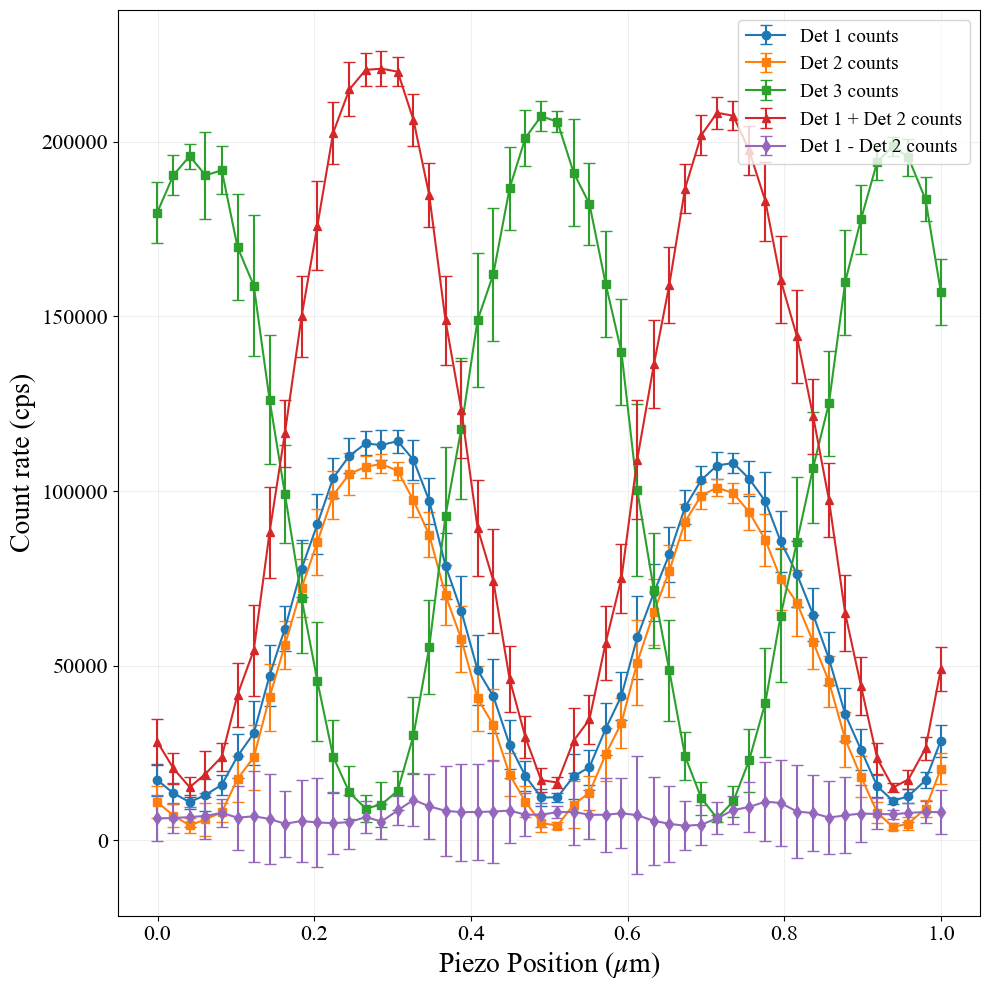

In [23]:
sum12  = mean1 + mean2
diff12 = mean1 - mean2

sum12_err  = np.sqrt(std1**2 + std2**2)
diff12_err = np.sqrt(std1**2 + std2**2)

plt.figure(figsize=(10, 10))

plt.errorbar(distArr_measured, mean1, yerr=std1,
             fmt='o-', capsize=4, label='Det 1 counts')

plt.errorbar(distArr_measured, mean2, yerr=std2,
             fmt='s-', capsize=4, label='Det 2 counts')
plt.errorbar(distArr_measured, mean3, yerr=std3,
             fmt='s-', capsize=4, label='Det 3 counts')

plt.errorbar(distArr_measured, sum12, yerr=sum12_err,
             fmt='^-', capsize=4, label='Det 1 + Det 2 counts')

plt.errorbar(distArr_measured, diff12, yerr=diff12_err,
             fmt='d-', capsize=4, label='Det 1 - Det 2 counts')

plt.xlabel("Piezo Position ($\\mu$m)", fontsize=20)
plt.ylabel("Count rate (cps)", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(alpha=0.2)
plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
def CalculateTheoryVelocities(eta, theta, phi0, N=50, step_nm=20.0, lambda_nm=925.0):
    # eta is a single fixed theory parameter
    # theta in degrees
    # phi0 is the initial phase in radians

    step_um = step_nm * 1e-3          # 20 nm = 0.02 micron
    lambda_um = lambda_nm * 1e-3      # 925 nm = 0.925 micron

    x_um = np.arange(N) * step_um     # 50 points: 0, 0.02, ..., 0.98 micron

    delta = np.sin(2 * np.radians(theta))**2
    epsilon = 1 - delta

    phi = phi0 + 4 * np.pi * x_um / lambda_um

    j = 0.5 * (1- 2 * eta)

    rho = 0.5 * (
        1
        + 2 * np.cos(phi) * np.sqrt(eta * (1 - eta)) * np.sqrt(epsilon)
    )

    Vel_value = j / rho

    Vel_vec = np.zeros((2, N))

    angle = np.arctan(Vel_value)

    Vx = np.sin(angle)
    Vy = np.cos(angle)

    Vel_vec[0, :] = Vx
    Vel_vec[1, :] = Vy

    Vel_mag = np.sqrt(Vx**2 + Vy**2)

    return Vel_vec, Vel_mag, Vel_value, phi, rho, j, x_um

In [26]:
# -------------------------
# Sinusoidal model
# -------------------------
def fringe_model(x, I0, A, k, phi):
    return I0 + A * np.cos(k * x + phi)

def goodness_of_fit(y, y_fit_at_data, yerr, n_params):
    residuals = y - y_fit_at_data

    chi2 = np.sum((residuals / yerr)**2)
    dof = len(y) - n_params
    red_chi2 = chi2 / dof

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot

    return chi2, dof, red_chi2, r2

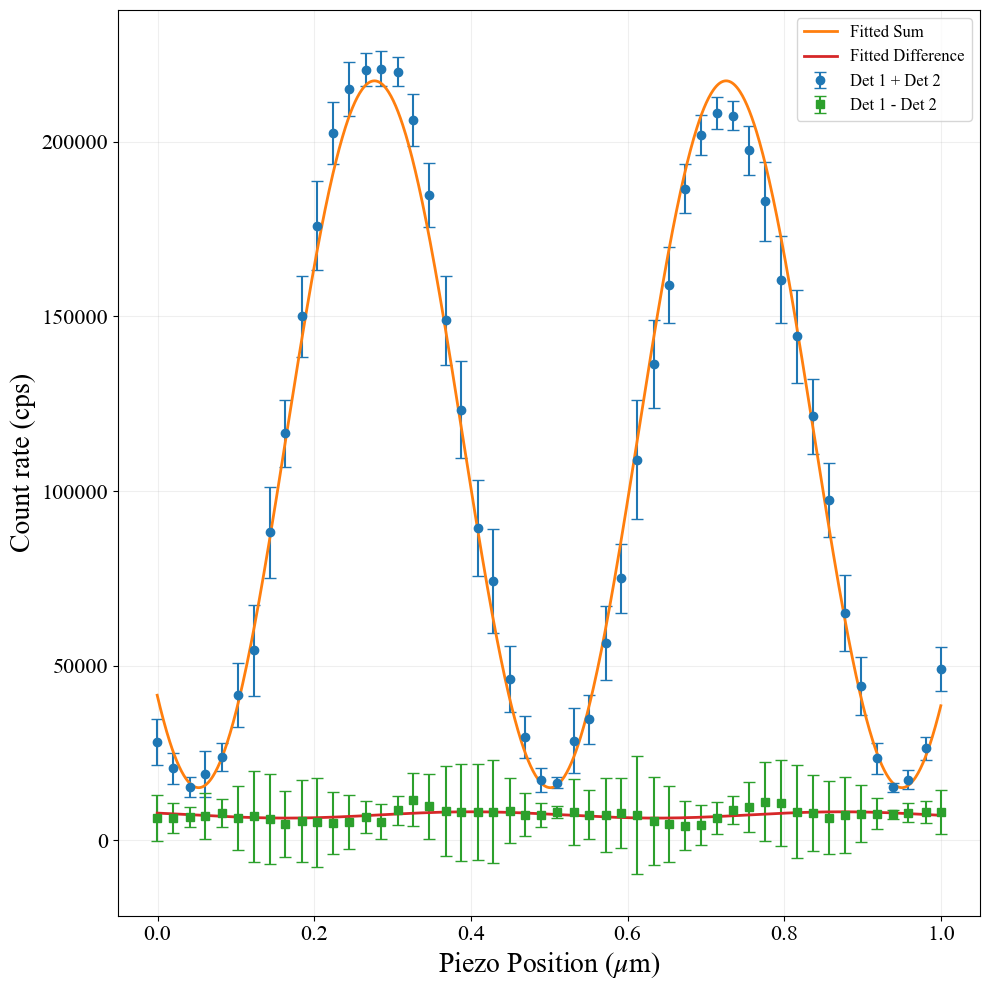

----- SUM -----
I0_sum = 116249.413 ± 857.515 cps
A_sum  = -101172.853 ± 921.600 cps
k_sum  = 13.996 ± 0.057 rad/μm
phi_sum = -0.732 ± 0.035 rad
Visibility_sum = 0.870

----- DIFFERENCE -----
I0_diff = 7273.964 ± 858.880 cps
A_diff  = 898.584 ± 1740.218 cps
k_diff  = 13.312 ± 3.013 rad/μm
phi_diff = 0.948 ± 1.846 rad
Amplitude ratio abs(A_diff / A_sum) = 0.009

Goodness of fit: SUM
Chi-square = 47.439
Degrees of freedom = 46
Reduced chi-square = 1.031
R^2 = 0.9909

Goodness of fit: DIFFERENCE
Chi-square = 2.016
Degrees of freedom = 46
Reduced chi-square = 0.044
R^2 = 0.2902


In [27]:
# -------------------------
# Prepare CW data
# -------------------------
x = distArr_measured

y_sum  = sum12
y_diff = diff12

yerr_sum  = sum12_err
yerr_diff = diff12_err

# -------------------------
# Initial guesses
# -------------------------
period_est = 0.46
k_guess = 2 * np.pi / period_est
phi_guess = 0

I0_sum_guess = np.mean(y_sum)
A_sum_guess  = (np.max(y_sum) - np.min(y_sum)) / 2

I0_diff_guess = np.mean(y_diff)
A_diff_guess  = (np.max(y_diff) - np.min(y_diff)) / 2

p0_sum  = [I0_sum_guess,  A_sum_guess,  k_guess, phi_guess]
p0_diff = [I0_diff_guess, A_diff_guess, k_guess, phi_guess]


# -------------------------
# Fit
# -------------------------
popt_sum, pcov_sum = curve_fit(
    fringe_model, x, y_sum,
    p0=p0_sum,
    sigma=yerr_sum,
    absolute_sigma=True,
    maxfev=10000
)

popt_diff, pcov_diff = curve_fit(
    fringe_model, x, y_diff,
    p0=p0_diff,
    sigma=yerr_diff,
    absolute_sigma=True,
    maxfev=10000
)

I0_sum_fit, A_sum_fit, k_sum_fit, phi_sum_fit = popt_sum
I0_diff_fit, A_diff_fit, k_diff_fit, phi_diff_fit = popt_diff

perr_sum  = np.sqrt(np.diag(pcov_sum))
perr_diff = np.sqrt(np.diag(pcov_diff))


# -------------------------
# Fitted curves
# -------------------------
x_fit = np.linspace(x.min(), x.max(), 1000)

y_fit_sum  = fringe_model(x_fit, *popt_sum)
y_fit_diff = fringe_model(x_fit, *popt_diff)

y_fit_sum_data  = fringe_model(x, *popt_sum)
y_fit_diff_data = fringe_model(x, *popt_diff)


# -------------------------
# Visibility / amplitude ratio
# -------------------------
I_max_sum = np.max(y_fit_sum)
I_min_sum = np.min(y_fit_sum)

visibility_sum = (I_max_sum - I_min_sum) / (I_max_sum + I_min_sum)
amp_ratio = abs(A_diff_fit / A_sum_fit)


# -------------------------
# Goodness of fit
# -------------------------
n_params = len(popt_sum)

chi2_sum, dof_sum, red_chi2_sum, r2_sum = goodness_of_fit(
    y_sum, y_fit_sum_data, yerr_sum, n_params
)

chi2_diff, dof_diff, red_chi2_diff, r2_diff = goodness_of_fit(
    y_diff, y_fit_diff_data, yerr_diff, n_params
)


# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10, 10))

plt.errorbar(
    x, y_sum, yerr=yerr_sum,
    fmt='o', capsize=4,
    label='Det 1 + Det 2'
)

plt.plot(
    x_fit, y_fit_sum,
    '-', linewidth=2,
    label='Fitted Sum'
)

plt.errorbar(
    x, y_diff, yerr=yerr_diff,
    fmt='s', capsize=4,
    label='Det 1 - Det 2'
)

plt.plot(
    x_fit, y_fit_diff,
    '-', linewidth=2,
    label='Fitted Difference'
)

plt.xlabel("Piezo Position ($\\mu$m)", fontsize=20)
plt.ylabel("Count rate (cps)", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(alpha=0.2)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()


# -------------------------
# Print results
# -------------------------
print("----- SUM -----")
print(f"I0_sum = {I0_sum_fit:.3f} ± {perr_sum[0]:.3f} cps")
print(f"A_sum  = {A_sum_fit:.3f} ± {perr_sum[1]:.3f} cps")
print(f"k_sum  = {k_sum_fit:.3f} ± {perr_sum[2]:.3f} rad/μm")
print(f"phi_sum = {phi_sum_fit:.3f} ± {perr_sum[3]:.3f} rad")
print(f"Visibility_sum = {visibility_sum:.3f}")

print("\n----- DIFFERENCE -----")
print(f"I0_diff = {I0_diff_fit:.3f} ± {perr_diff[0]:.3f} cps")
print(f"A_diff  = {A_diff_fit:.3f} ± {perr_diff[1]:.3f} cps")
print(f"k_diff  = {k_diff_fit:.3f} ± {perr_diff[2]:.3f} rad/μm")
print(f"phi_diff = {phi_diff_fit:.3f} ± {perr_diff[3]:.3f} rad")
print(f"Amplitude ratio abs(A_diff / A_sum) = {amp_ratio:.3f}")

print("\nGoodness of fit: SUM")
print(f"Chi-square = {chi2_sum:.3f}")
print(f"Degrees of freedom = {dof_sum}")
print(f"Reduced chi-square = {red_chi2_sum:.3f}")
print(f"R^2 = {r2_sum:.4f}")

print("\nGoodness of fit: DIFFERENCE")
print(f"Chi-square = {chi2_diff:.3f}")
print(f"Degrees of freedom = {dof_diff}")
print(f"Reduced chi-square = {red_chi2_diff:.3f}")
print(f"R^2 = {r2_diff:.4f}")

## peak normalised data

In [28]:
Normfac = np.max(sum12)

# Normalised quantities
mean1_n = mean1 / Normfac
mean2_n = mean2 / Normfac
mean3_n = mean3 / Normfac

std1_n  = std1 / Normfac
std2_n  = std2 / Normfac
std3_n  = std3 / Normfac

sum12_n  = sum12 / Normfac
diff12_n = diff12 / Normfac

sum12_err_n  = sum12_err / Normfac
diff12_err_n = diff12_err / Normfac

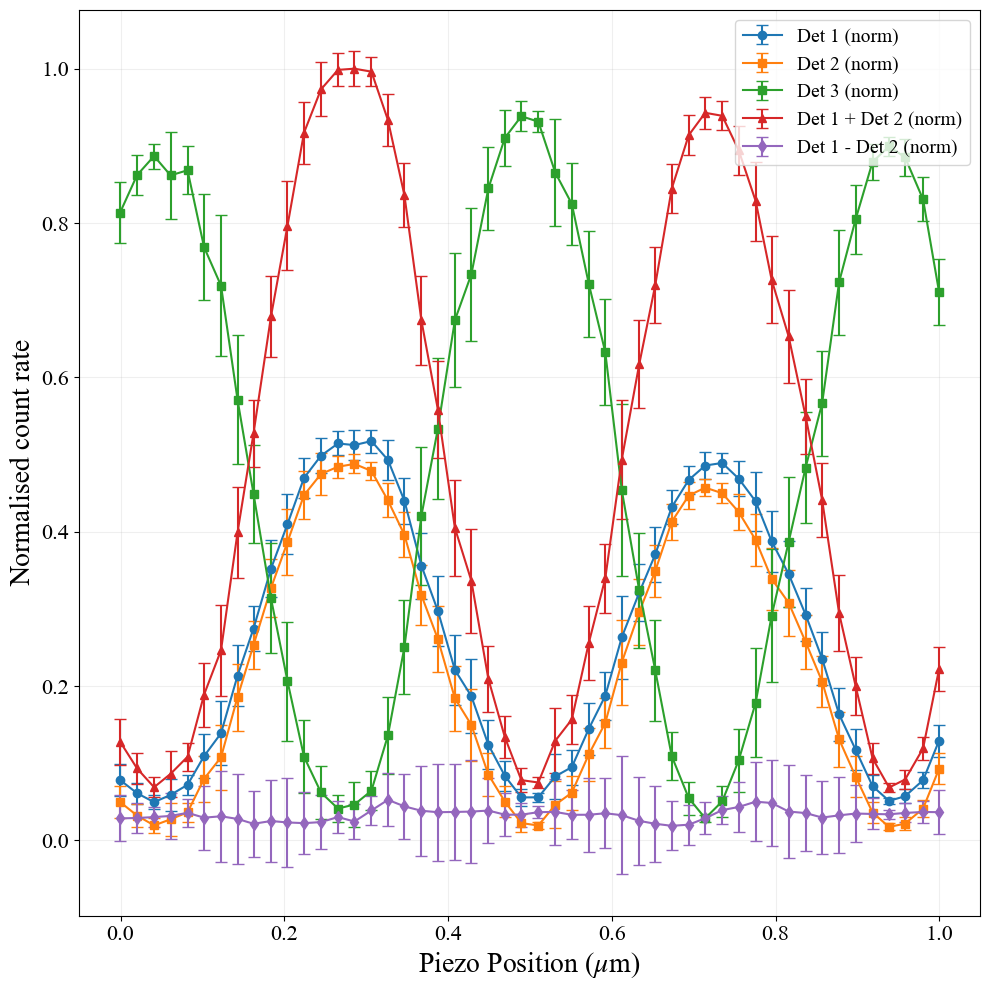

In [29]:
plt.figure(figsize=(10, 10))

plt.errorbar(distArr_measured, mean1_n, yerr=std1_n,
             fmt='o-', capsize=4, label='Det 1 (norm)')

plt.errorbar(distArr_measured, mean2_n, yerr=std2_n,
             fmt='s-', capsize=4, label='Det 2 (norm)')

plt.errorbar(distArr_measured, mean3_n, yerr=std3_n,
             fmt='s-', capsize=4, label='Det 3 (norm)')

plt.errorbar(distArr_measured, sum12_n, yerr=sum12_err_n,
             fmt='^-', capsize=4, label='Det 1 + Det 2 (norm)')

plt.errorbar(distArr_measured, diff12_n, yerr=diff12_err_n,
             fmt='d-', capsize=4, label='Det 1 - Det 2 (norm)')

plt.xlabel("Piezo Position ($\\mu$m)", fontsize=20)
plt.ylabel("Normalised count rate", fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(alpha=0.2)
plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()
plt.show()

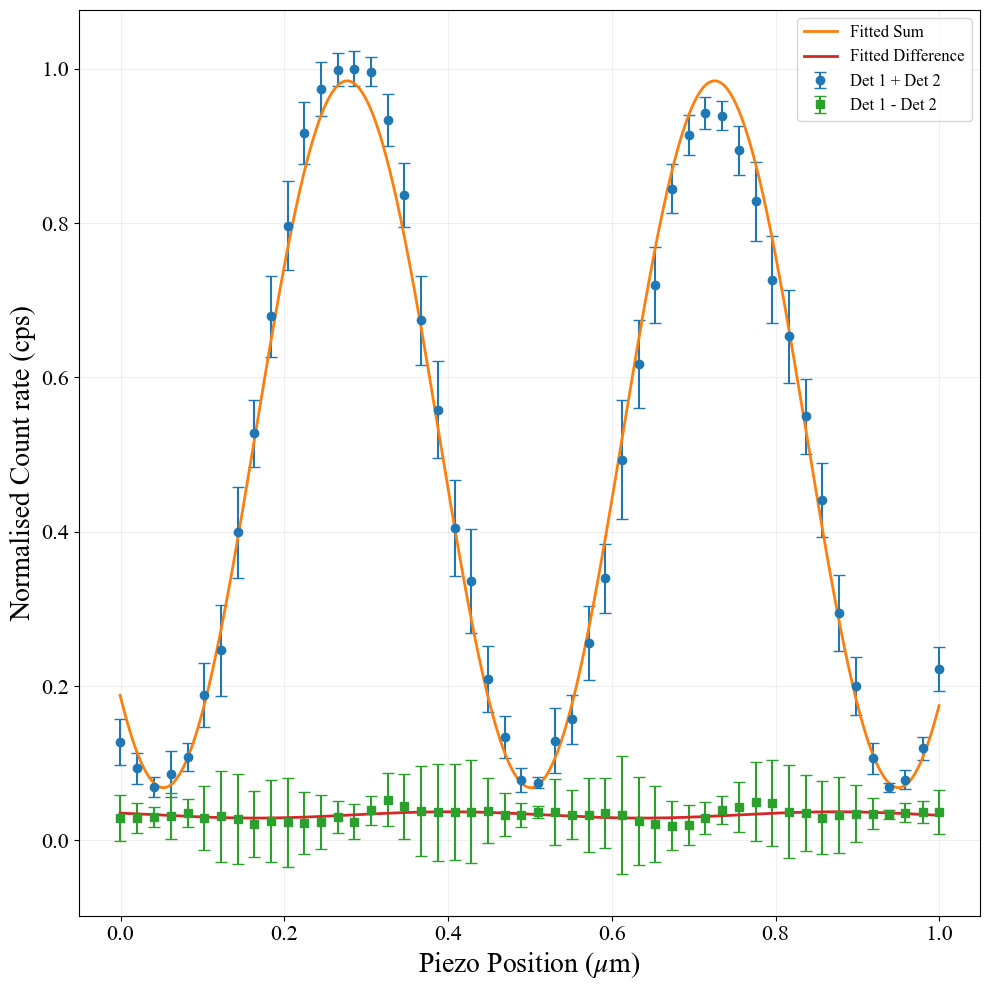

----- SUM -----
I0_sum = 0.526 ± 0.004 cps
A_sum  = -0.458 ± 0.004 cps
k_sum  = 13.996 ± 0.057 rad/μm
phi_sum = -0.732 ± 0.035 rad
Visibility_sum = 0.870

----- DIFFERENCE -----
I0_diff = 0.033 ± 0.004 cps
A_diff  = 0.004 ± 0.008 cps
k_diff  = 13.312 ± 3.013 rad/μm
phi_diff = 0.948 ± 1.846 rad
Amplitude ratio abs(A_diff / A_sum) = 0.009

Goodness of fit: SUM
Chi-square = 47.439
Degrees of freedom = 46
Reduced chi-square = 1.031
R^2 = 0.9909

Goodness of fit: DIFFERENCE
Chi-square = 2.016
Degrees of freedom = 46
Reduced chi-square = 0.044
R^2 = 0.2902


In [30]:
# fitting normalised data

x = distArr_measured

y_sum  = sum12_n
y_diff = diff12_n

yerr_sum  = sum12_err_n
yerr_diff = diff12_err_n

# -------------------------
# Initial guesses
# -------------------------
period_est = 0.46
k_guess = 2 * np.pi / period_est
phi_guess = 0

I0_sum_guess = np.mean(y_sum)
A_sum_guess  = (np.max(y_sum) - np.min(y_sum)) / 2

I0_diff_guess = np.mean(y_diff)
A_diff_guess  = (np.max(y_diff) - np.min(y_diff)) / 2

p0_sum  = [I0_sum_guess,  A_sum_guess,  k_guess, phi_guess]
p0_diff = [I0_diff_guess, A_diff_guess, k_guess, phi_guess]


# -------------------------
# Fit
# -------------------------
popt_sum, pcov_sum = curve_fit(
    fringe_model, x, y_sum,
    p0=p0_sum,
    sigma=yerr_sum,
    absolute_sigma=True,
    maxfev=10000
)

popt_diff, pcov_diff = curve_fit(
    fringe_model, x, y_diff,
    p0=p0_diff,
    sigma=yerr_diff,
    absolute_sigma=True,
    maxfev=10000
)

I0_sum_fit, A_sum_fit, k_sum_fit, phi_sum_fit = popt_sum
I0_diff_fit, A_diff_fit, k_diff_fit, phi_diff_fit = popt_diff

perr_sum  = np.sqrt(np.diag(pcov_sum))
perr_diff = np.sqrt(np.diag(pcov_diff))


# -------------------------
# Fitted curves
# -------------------------
x_fit = np.linspace(x.min(), x.max(), 1000)

y_fit_sum  = fringe_model(x_fit, *popt_sum)
y_fit_diff = fringe_model(x_fit, *popt_diff)

y_fit_sum_data  = fringe_model(x, *popt_sum)
y_fit_diff_data = fringe_model(x, *popt_diff)


# -------------------------
# Visibility / amplitude ratio
# -------------------------
I_max_sum = np.max(y_fit_sum)
I_min_sum = np.min(y_fit_sum)

visibility_sum = (I_max_sum - I_min_sum) / (I_max_sum + I_min_sum)
amp_ratio = abs(A_diff_fit / A_sum_fit)


# -------------------------
# Goodness of fit
# -------------------------
n_params = len(popt_sum)

chi2_sum, dof_sum, red_chi2_sum, r2_sum = goodness_of_fit(
    y_sum, y_fit_sum_data, yerr_sum, n_params
)

chi2_diff, dof_diff, red_chi2_diff, r2_diff = goodness_of_fit(
    y_diff, y_fit_diff_data, yerr_diff, n_params
)


# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10, 10))

plt.errorbar(
    x, y_sum, yerr=yerr_sum,
    fmt='o', capsize=4,
    label='Det 1 + Det 2'
)

plt.plot(
    x_fit, y_fit_sum,
    '-', linewidth=2,
    label='Fitted Sum'
)

plt.errorbar(
    x, y_diff, yerr=yerr_diff,
    fmt='s', capsize=4,
    label='Det 1 - Det 2'
)

plt.plot(
    x_fit, y_fit_diff,
    '-', linewidth=2,
    label='Fitted Difference'
)

plt.xlabel("Piezo Position ($\\mu$m)", fontsize=20)
plt.ylabel("Normalised Count rate (cps)", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(alpha=0.2)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()


# -------------------------
# Print results
# -------------------------
print("----- SUM -----")
print(f"I0_sum = {I0_sum_fit:.3f} ± {perr_sum[0]:.3f} cps")
print(f"A_sum  = {A_sum_fit:.3f} ± {perr_sum[1]:.3f} cps")
print(f"k_sum  = {k_sum_fit:.3f} ± {perr_sum[2]:.3f} rad/μm")
print(f"phi_sum = {phi_sum_fit:.3f} ± {perr_sum[3]:.3f} rad")
print(f"Visibility_sum = {visibility_sum:.3f}")

print("\n----- DIFFERENCE -----")
print(f"I0_diff = {I0_diff_fit:.3f} ± {perr_diff[0]:.3f} cps")
print(f"A_diff  = {A_diff_fit:.3f} ± {perr_diff[1]:.3f} cps")
print(f"k_diff  = {k_diff_fit:.3f} ± {perr_diff[2]:.3f} rad/μm")
print(f"phi_diff = {phi_diff_fit:.3f} ± {perr_diff[3]:.3f} rad")
print(f"Amplitude ratio abs(A_diff / A_sum) = {amp_ratio:.3f}")

print("\nGoodness of fit: SUM")
print(f"Chi-square = {chi2_sum:.3f}")
print(f"Degrees of freedom = {dof_sum}")
print(f"Reduced chi-square = {red_chi2_sum:.3f}")
print(f"R^2 = {r2_sum:.4f}")

print("\nGoodness of fit: DIFFERENCE")
print(f"Chi-square = {chi2_diff:.3f}")
print(f"Degrees of freedom = {dof_diff}")
print(f"Reduced chi-square = {red_chi2_diff:.3f}")
print(f"R^2 = {r2_diff:.4f}")

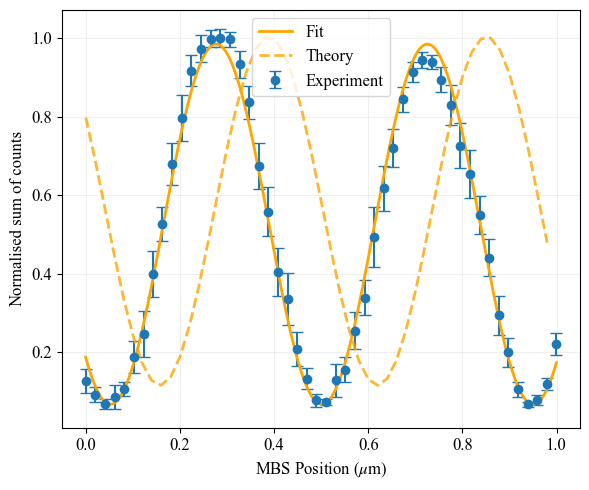

----- EXPERIMENTAL SUM -----
I0_sum = 0.526 ± 0.004
A_sum = -0.458 ± 0.004
k_sum = 13.996 ± 0.057 rad/μm
phi_sum = -0.732 ± 0.035 rad
Visibility_sum = 0.870

Goodness of fit
Chi-square = 47.439
Degrees of freedom = 46
Reduced chi-square = 1.031
R² = 0.9909


In [31]:
# ============================================================
# Experimental sum data
# ============================================================
x = distArr_measured
y_sum = sum12_n
yerr_sum = sum12_err_n


# -------------------------
# Initial guesses
# -------------------------
period_est = 0.46
k_guess = 2 * np.pi / period_est
phi_guess = 0

I0_sum_guess = np.mean(y_sum)
A_sum_guess = (np.max(y_sum) - np.min(y_sum)) / 2

p0_sum = [
    I0_sum_guess,
    A_sum_guess,
    k_guess,
    phi_guess
]


# -------------------------
# Fit experimental sum
# -------------------------
popt_sum, pcov_sum = curve_fit(
    fringe_model,
    x,
    y_sum,
    p0=p0_sum,
    sigma=yerr_sum,
    absolute_sigma=True,
    maxfev=10000
)

I0_sum_fit, A_sum_fit, k_sum_fit, phi_sum_fit = popt_sum
perr_sum = np.sqrt(np.diag(pcov_sum))


# -------------------------
# Experimental fitted curve
# -------------------------
x_fit = np.linspace(x.min(), x.max(), 1000)

y_fit_sum = fringe_model(x_fit, *popt_sum)
y_fit_sum_data = fringe_model(x, *popt_sum)


# ============================================================
# Theoretical curve
# ============================================================
eta = 0.2
theta = 4.0
fringe_start = 0.16

phi0 = 2 * np.pi * fringe_start

Vel_vec, Vel_mag, Vel_value, phi, rho, j, x_um = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta,
        phi0=phi0,
        N=len(x),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

# Peak-normalized theoretical density
rho_n = rho / np.max(rho)


# -------------------------
# Experimental visibility
# -------------------------
I_max_sum = np.max(y_fit_sum)
I_min_sum = np.min(y_fit_sum)

visibility_sum = (
    (I_max_sum - I_min_sum)
    / (I_max_sum + I_min_sum)
)


# -------------------------
# Goodness of fit
# -------------------------
n_params = len(popt_sum)

chi2_sum, dof_sum, red_chi2_sum, r2_sum = goodness_of_fit(
    y_sum,
    y_fit_sum_data,
    yerr_sum,
    n_params
)


# ============================================================
# Combined experimental and theoretical plot
# ============================================================
plt.figure(figsize=(6, 5))

plt.errorbar(
    x,
    y_sum,
    yerr=yerr_sum,
    fmt='o',
    capsize=4,
    label='Experiment'
)

plt.plot(
    x_fit,
    y_fit_sum,
    linewidth=2,
    linestyle= '-',
    color = 'orange',
    label='Fit'
)

plt.plot(
    x_um,
    rho_n,
    linestyle = '--',
    linewidth=2,
    alpha = 0.8,
    color = 'orange',
    label='Theory'
)

plt.xlabel(r"MBS Position ($\mu$m)", fontsize=12)
plt.ylabel("Normalised sum of counts", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(alpha=0.2)
plt.legend(fontsize=12, loc = 'best')
plt.tight_layout()
plt.show()


# -------------------------
# Print fit results
# -------------------------
print("----- EXPERIMENTAL SUM -----")
print(f"I0_sum = {I0_sum_fit:.3f} ± {perr_sum[0]:.3f}")
print(f"A_sum = {A_sum_fit:.3f} ± {perr_sum[1]:.3f}")
print(f"k_sum = {k_sum_fit:.3f} ± {perr_sum[2]:.3f} rad/μm")
print(f"phi_sum = {phi_sum_fit:.3f} ± {perr_sum[3]:.3f} rad")
print(f"Visibility_sum = {visibility_sum:.3f}")

print("\nGoodness of fit")
print(f"Chi-square = {chi2_sum:.3f}")
print(f"Degrees of freedom = {dof_sum}")
print(f"Reduced chi-square = {red_chi2_sum:.3f}")
print(f"R² = {r2_sum:.4f}")

## Velocity field from raw data

In [32]:
def CalculateVelocities(CountsData, diff_const, theta, detect_eff_correction, exptData = False):        # theta in deg
    channelCount, distCount = CountsData.shape

    if exptData:                                                  # switch between the two num def if you want data for each point or just the base of the unwanted oscilations
        num = CountsData[0, :] - detect_eff_correction * CountsData[1, :]
    else:
        num = diff_const
        
    den = CountsData[0, :] + detect_eff_correction * CountsData[1, :]

    if theta != 0:
        #scale = np.sqrt(np.sin(2 * np.radians(theta)))
        scale = np.sin(2 * np.radians(theta))           # removed the square root as delta is actually (sin(2\theta))^2  dated 29012026
        Vel_value = num / (scale * den)      
    else:
        Vel_value = num / den
        print("You can't get velocity without hwp offset")

    Vel_vec = np.zeros((2, distCount))    
      

    angle = np.arctan(Vel_value)

    Vx = np.sin(angle)      # x component (space)
    Vy = np.cos(angle)      # t component (time, >0)

    Vel_vec[0, :] = Vx
    Vel_vec[1, :] = Vy

    Vel_mag = np.sqrt(Vx**2 + Vy**2)
    
    return Vel_vec, Vel_mag

In [33]:
meanAll = np.vstack((mean1_n, mean2_n))
meanAll.shape

theta_deg = AngleOfFirstWaveplate.item()
detect_eff_correction = 1.0
Vel_vec, Vel_mag = CalculateVelocities(meanAll, diff_const=I0_diff_fit*1e-6, theta = 4.0, detect_eff_correction=detect_eff_correction, exptData=True)

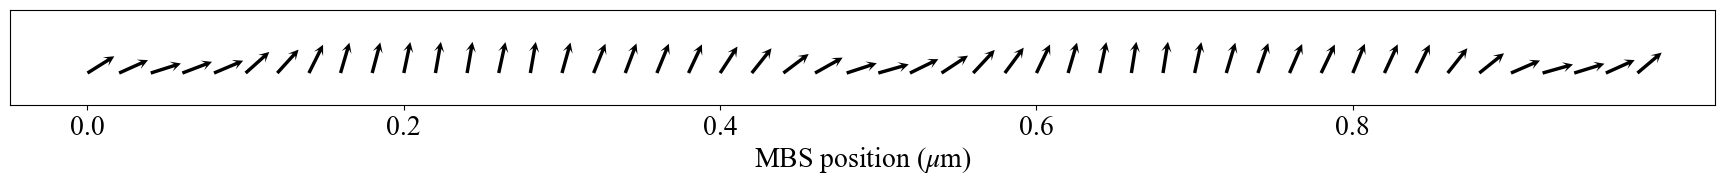

In [34]:
Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]

N = Vx.size
x_positions = np.arange(N)         # 1D positions
y_positions = np.zeros(N)           # Put all arrows on y = 0 axis

plt.figure(figsize=(22,4))

plt.quiver(
    x_positions, y_positions,   # positions of arrows
    Vx, Vy,                     # arrow components
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.002,
    headwidth=3,
    headlength=3,
    headaxislength=2
)

plt.gca().set_aspect('equal', adjustable='box')

plt.ylim(-1, 2)

# convert x-axis tick labels from index to piezo position
step_um = 0.02

tick_positions = np.arange(0, N, 10)          # index positions: 0, 10, 20, 30, 40
tick_labels = tick_positions * step_um        # micron labels: 0.0, 0.2, 0.4, 0.6, 0.8

plt.xticks(
    tick_positions,
    [f"{x:.1f}" for x in tick_labels], fontsize = 20
)
plt.yticks([]) # want no y ticks
plt.xlabel("MBS position ($\\mu$m)", fontsize = 20)
#plt.ylabel("Vector direction")
#plt.title("Theoretical 1D Bohmian Vector")
#plt.grid(True, alpha = 0.5)
plt.show()


In [35]:
theta_deg = 4
scale = (np.sin(2 * np.radians(theta_deg)))
velocity = (mean1_n - mean2_n)/(scale*(mean1_n + mean2_n))
angle = np.degrees(np.arctan(velocity))
angle
# print(np.mean(angle))
# print(np.std(angle))

array([57.99240502, 65.88960868, 72.37427689, 69.24064571, 67.06715439,
       48.21335899, 42.27005598, 26.56247429, 16.29617541, 14.84212106,
       11.82096843,  9.90522675,  9.90329948, 12.24348562,  9.94264065,
       15.60942474, 22.00010639, 20.72224442, 22.23187137, 25.14544415,
       33.13443015, 38.54168296, 52.97020956, 60.77575395, 71.90842498,
       74.06553037, 63.98062816, 56.65081679, 42.95506512, 36.61534114,
       25.39774266, 16.37054214, 12.09426243,  9.10132793,  9.06061894,
       12.30605117, 16.68924114, 19.15742139, 23.48439508, 25.5999426 ,
       22.32616429, 24.81251306, 25.69092689, 38.33625973, 51.2825425 ,
       66.63303655, 74.22125908, 72.84051574, 65.74688464, 49.76843461])

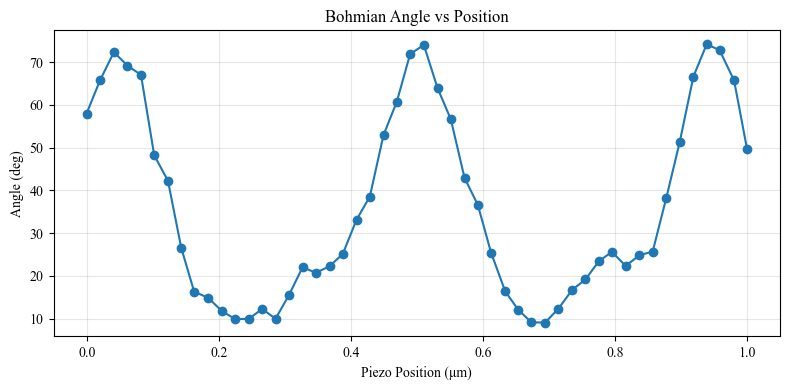

In [36]:
plt.figure(figsize=(8,4))

plt.plot(distArr_measured, angle, 'o-', linewidth=1.5)

# plt.axhline(np.mean(angle), color='r', linestyle='--',
#             label=f"Mean = {np.mean(angle):.2f}°")

plt.xlabel("Piezo Position (μm)")
plt.ylabel("Angle (deg)")
plt.title("Bohmian Angle vs Position")
plt.grid(True, alpha=0.3)
#plt.legend()
plt.tight_layout()
plt.show()

## stacking the 1-d field to create 2-d

### stacking for traj from left to right

Discrete sum = 2500.0
Area normalisation = 1.0


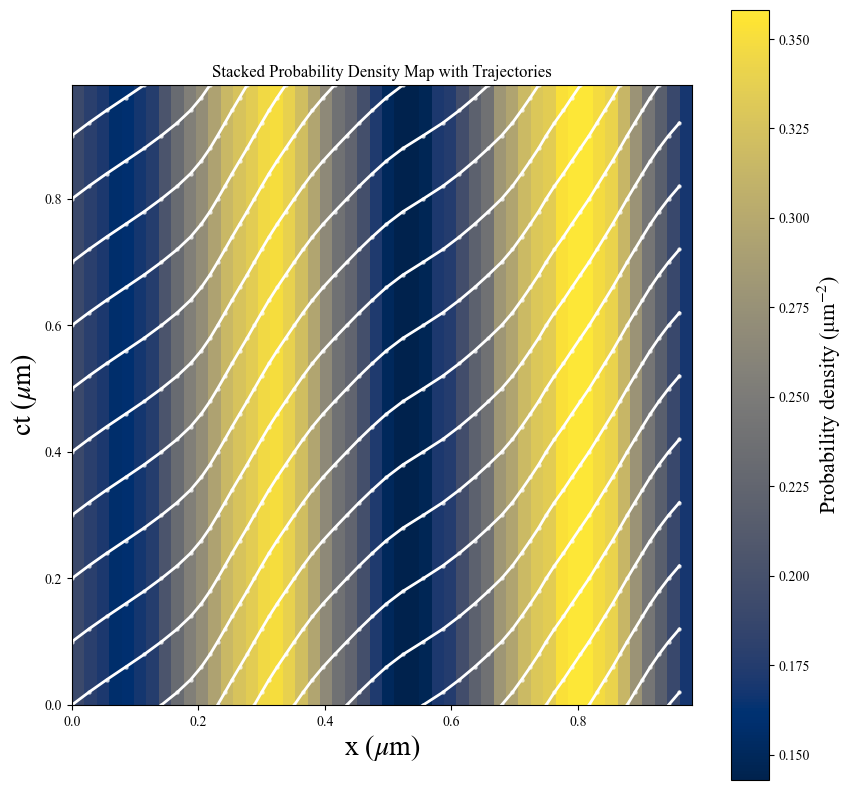

In [756]:
Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]

N = Vx.size
n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

# probability density
dx = 0.02   # micron, physical scan spacing
dy = 0.02   # micron, artificial ct spacing chosen to match x spacing

prob_1d = mean1_n + mean2_n
prob_1d = np.asarray(prob_1d, dtype=float)
prob_1d = np.nan_to_num(prob_1d, nan=0.0)
prob_1d[prob_1d < 0] = 0

# stack into 2D
prob_2d = np.tile(prob_1d, (n_rows_top + n_rows_bottom, 1))

# area normalise
prob_2d /= np.sum(prob_2d) * dx * dy

print("Discrete sum =", np.sum(prob_2d))
print("Area normalisation =", np.sum(prob_2d) * dx * dy)

y_vals = np.arange(-n_rows_bottom, n_rows_top) * y_spacing

plt.figure(figsize=(10, 10))

plt.imshow(
    prob_2d,
    origin='lower',
    aspect='equal',
    cmap='cividis',
    extent=[0, N-1, y_vals[0], y_vals[-1]]
)

cbar = plt.colorbar()
cbar.set_label("Probability density (μm$^{-2}$)", fontsize=16)

# trajectories
left_start_rows = np.arange(-n_rows_bottom, n_rows_top, 5)

for j0 in left_start_rows:
    xs = [0]
    ys = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    # integrate upward
    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)
        
    plt.plot(xs, ys, linewidth=2, color='white')
    plt.scatter(xs, ys, s=5, color='white', alpha=0.6)
    

ticksforfig = np.arange(0, 1, 0.2)         # desired ticks

xticks = ticksforfig / dx                  # Convert to index positions
yticks = ticksforfig / dy

# Apply ticks
plt.xticks(xticks, [f"{ticks:.1f}" for ticks in ticksforfig])
plt.yticks(yticks, [f"{ticks:.1f}" for ticks in ticksforfig])

# Labels
plt.xlabel("x ($\\mu$m)", fontsize=20)
plt.ylabel("ct ($\\mu$m)", fontsize=20)    

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(0, N-1)
plt.ylim(0, N-1)
# plt.xlabel("Spatial index")
# plt.ylabel("Stacked time index")

plt.title("Stacked Probability Density Map with Trajectories")
plt.grid(False)
plt.show()
        

Discrete sum = 2499.999999999999
Area normalisation = 0.9999999999999998


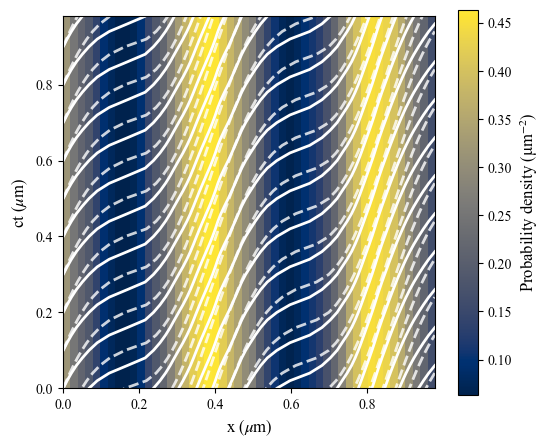

In [776]:
Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# ============================================================
# Theoretical velocities
# ============================================================
eta = 0.2
theta_theory = 4.0
fringe_start = 0.16

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = CalculateTheoryVelocities(
    eta=eta,
    theta=theta_theory,
    phi0=phi0,
    N=len(Vx),
    step_nm=20.0,
    lambda_nm=925.0
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]


# ============================================================
# Probability density background from experiment
# ============================================================
N = Vx.size
n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02   # micron
dy = 0.02   # micron

prob_1d = mean1_n + mean2_n
prob_1d = np.asarray(prob_1d, dtype=float)
prob_1d = np.nan_to_num(prob_1d, nan=0.0)
prob_1d[prob_1d < 0] = 0

prob_2d = np.tile(prob_1d, (n_rows_top + n_rows_bottom, 1))
prob_2d /= np.sum(prob_2d) * dx * dy

print("Discrete sum =", np.sum(prob_2d))
print("Area normalisation =", np.sum(prob_2d) * dx * dy)

y_vals = np.arange(-n_rows_bottom, n_rows_top) * y_spacing


# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(6, 5))

plt.imshow(
    prob_2d,
    origin='lower',
    aspect='equal',
    cmap='cividis',
    extent=[0, N-1, y_vals[0], y_vals[-1]]
)

cbar = plt.colorbar()
cbar.set_label("Probability density (μm$^{-2}$)", fontsize=12)

left_start_rows = np.arange(-n_rows_bottom, n_rows_top, 5)

# -------------------------
# Experimental trajectories: white solid
# -------------------------
for j0 in left_start_rows:
    xs = [0]
    ys = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    plt.plot(xs, ys, linewidth=2, color='white')
    #plt.scatter(xs, ys, s=5, color='white', alpha=0.6)


# -------------------------
# Theoretical trajectories: white dashed
# -------------------------
for j0 in left_start_rows:
    xs_th = [0]
    ys_th = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx_th)
        vy = np.interp(x_current, np.arange(N), Vy_th)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    plt.plot(xs_th, ys_th, '--', linewidth=2, color='white', alpha = 0.8)


# ============================================================
# Axes
# ============================================================
ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy

plt.xticks(xticks, [f"{ticks:.1f}" for ticks in ticksforfig])
plt.yticks(yticks, [f"{ticks:.1f}" for ticks in ticksforfig])

plt.xlabel("x ($\\mu$m)", fontsize=12)
plt.ylabel("ct ($\\mu$m)", fontsize=12)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(0, N-1)
plt.ylim(0, N-1)

#plt.title("Stacked Probability Density Map with Experimental and Theoretical Trajectories")
plt.grid(False)
plt.show()

### stacking for traj from right to left

Discrete sum = 2500.0
Area normalisation = 1.0


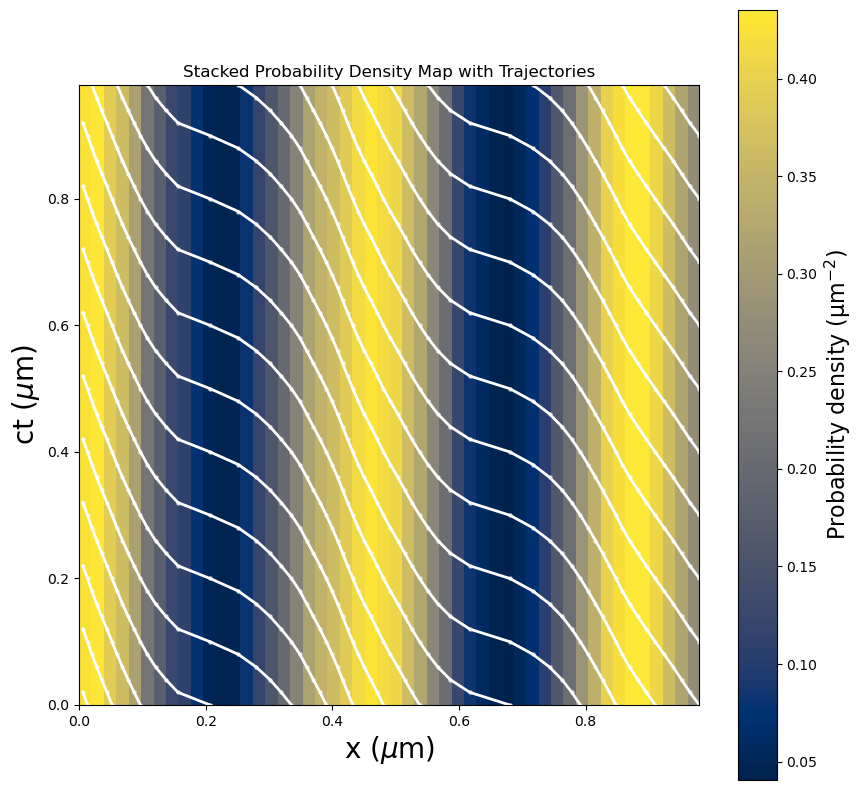

In [565]:
Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]

N = Vx.size
n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

# probability density
dx = 0.02   # micron, physical scan spacing
dy = 0.02   # micron, artificial ct spacing chosen to match x spacing

prob_1d = mean1_n + mean2_n
prob_1d = np.asarray(prob_1d, dtype=float)
prob_1d = np.nan_to_num(prob_1d, nan=0.0)
prob_1d[prob_1d < 0] = 0

# stack into 2D
prob_2d = np.tile(prob_1d, (n_rows_top + n_rows_bottom, 1))

# area normalise
prob_2d /= np.sum(prob_2d) * dx * dy

print("Discrete sum =", np.sum(prob_2d))
print("Area normalisation =", np.sum(prob_2d) * dx * dy)

y_vals = np.arange(-n_rows_bottom, n_rows_top) * y_spacing

plt.figure(figsize=(10, 10))

plt.imshow(
    prob_2d,
    origin='lower',
    aspect='equal',
    cmap='cividis',
    extent=[0, N-1, y_vals[0], y_vals[-1]]
)

cbar = plt.colorbar()
cbar.set_label("Probability density (μm$^{-2}$)", fontsize=16)

# trajectories starting from the right time axis
right_start_rows = np.arange(-n_rows_bottom, n_rows_top, 5)

for j0 in right_start_rows:
    xs = [N - 1]
    ys = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    # integrate upward, but from right to left
    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        # minus sign makes trajectories enter from the right
        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    plt.plot(xs, ys, linewidth=2, color='white')
    plt.scatter(xs, ys, s=5, color='white', alpha=0.6)
    
ticksforfig = np.arange(0, 1, 0.2)         # desired ticks

xticks = ticksforfig / dx                  # Convert to index positions
yticks = ticksforfig / dy

# Apply ticks
plt.xticks(xticks, [f"{ticks:.1f}" for ticks in ticksforfig])
plt.yticks(yticks, [f"{ticks:.1f}" for ticks in ticksforfig])

# Labels
plt.xlabel("x ($\\mu$m)", fontsize=20)
plt.ylabel("ct ($\\mu$m)", fontsize=20)    

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(0, N-1)
plt.ylim(0, N-1)
# plt.xlabel("Spatial index")
# plt.ylabel("Stacked time index")

plt.title("Stacked Probability Density Map with Trajectories")
plt.grid(False)
plt.show()

## Analysis from Raw Tags

In [ ]:
def veto_events_from_tags_pairwise_return_tags(
    timestamps_ps,
    channel_ids,
    kept_channels=(1, 2),
    coincidence_window_ps=150,
    cross_veto_pairs=((1,2), (1,3), (2,3))
):
    # Convert inputs to numpy arrays 
    ts_all = np.asarray(timestamps_ps, dtype=np.int64)
    ch_all = np.asarray(channel_ids, dtype=np.int32)

    # Handle empty input (no events recorded)
    if ts_all.size == 0:
        keep = np.zeros(0, dtype=bool)
        counts = {c: 0 for c in kept_channels}
        return keep, counts, ts_all, ch_all

    # Sort events by time 
    order = np.argsort(ts_all)
    ts_all = ts_all[order]
    ch_all = ch_all[order]

    N = ts_all.size

    # Boolean data type for keep: True = event survives veto, False = discarded
    keep = np.ones(N, dtype=bool)

    # Build mapping: channel to indices of events in that channel
    # Example: chan_to_idx[1] = indices where ch_all == 1
    chan_to_idx = {}
    for c in np.unique(ch_all):
        chan_to_idx[c] = np.where(ch_all == c)[0]

    # Coincidence time window (ps)
    window = int(coincidence_window_ps)

    # Build unique unordered channel pairs for veto
    # example: (1,2) and (2,1) treated as same and stored as (1,2)
    pairs_set = set()
    for a, b in cross_veto_pairs:
        if a != b:
            pairs_set.add(tuple(sorted((a, b))))

    # Loop over each channel pair (1–2, 1–3, 2–3)
    for a, b in pairs_set:

        # Skip if either channel not present in data
        if a not in chan_to_idx or b not in chan_to_idx:
            continue

        # Indices and timestamps for each channel
        idx_a = chan_to_idx[a]
        idx_b = chan_to_idx[b]
        t_a = ts_all[idx_a]
        t_b = ts_all[idx_b]

        # Two-pointer scan through both time arrays
        i = 0
        j = 0

        while i < t_a.size and j < t_b.size:
            dt = t_b[j] - t_a[i]

            if abs(dt) <= window:
                # if Coincidence found, veto bOTH events
                keep[idx_a[i]] = False
                keep[idx_b[j]] = False

                # Move both pointers forward (avoid double counting)
                i += 1
                j += 1

            elif dt > window:
                # Event in b is too late --- move a forward
                i += 1
            else:
                # Event in a is too late --- move b forward
                j += 1

    # Count surviving events only in desired channels (1 and 2)
    counts = {}
    for c in kept_channels:
        counts[c] = int(np.sum(keep & (ch_all == c)))

    # Return:
    # keep: which events survived veto
    # counts: final counts per kept channel
    # ts_all, ch_all : sorted arrays 
    return keep, counts, ts_all, ch_all

### excute raw tag post selection (vetoing)

In [ ]:
# Splitting ratio for this dataset
split_ratio = (30, 70)


binwidth_ps = int(bin_duration_s * 1e12)

distCount = distArr_measured.size

veto_total_counts = np.zeros((2, distCount), dtype=int)
veto_mean_rates   = np.zeros((2, distCount), dtype=float)
veto_std_rates    = np.zeros((2, distCount), dtype=float)

for idist in range(distCount):

    # save_dir / filename_RawTags / RawtagMountPos{idist} / stream_tags_pos_{idist}.npz
    pos_dir = os.path.join(RAW_BASE, f"RawtagMountPos{idist}")
    raw_npz = os.path.join(pos_dir, f"stream_tags_pos_{idist}.npz")

    print(f"\n[post] position {idist}, loading {raw_npz}")

    raw = np.load(raw_npz)

    ts = raw["timestamps_ps"]
    ch = raw["channel_ids"]

    event_types = (
        raw["event_types"]
        if "event_types" in raw.files and raw["event_types"].size
        else None
    )

    count_time_s = float(raw["count_time_s"][0])

    if event_types is not None:
        good = (event_types == 0)
        ts = ts[good]
        ch = ch[good]

    keep, counts_dict, ts_sorted, ch_sorted = veto_events_from_tags_pairwise_return_tags(
        ts,
        ch,
        kept_channels=(1, 2),
        coincidence_window_ps=1000,
        cross_veto_pairs=((1,2), (1,3), (2,3))
    )

    ts_keep = ts_sorted[keep]
    ch_keep = ch_sorted[keep]

    # shift time origin to first tag, or to zero if stream already starts near zero
    t0 = ts_keep.min() if ts_keep.size > 0 else 0
    t_rel = ts_keep - t0

    for ich, ch_id in enumerate((1, 2)):
        ts_ch = t_rel[ch_keep == ch_id]

        bin_index = (ts_ch // binwidth_ps).astype(int)

        valid = (bin_index >= 0) & (bin_index < num_measurements)
        bin_index = bin_index[valid]

        counts_per_bin = np.bincount(
            bin_index,
            minlength=num_measurements
        )

        total = counts_per_bin.sum()
        mean_rate = total / count_time_s
        std_rate = counts_per_bin.std(ddof=1) / bin_duration_s

        veto_total_counts[ich, idist] = total
        veto_mean_rates[ich, idist] = mean_rate
        veto_std_rates[ich, idist] = std_rate

        print(
            f"Ch {ch_id}: veto total = {total}, "
            f"mean = {mean_rate:.3e} cps, std = {std_rate:.3e} cps"
        )

# Create RAW_BASE/TagProcessedData if it does not already exist
processed_dir = os.path.join(RAW_BASE, "TagProcessedData")
os.makedirs(processed_dir, exist_ok=True)

# Build output filename and path
output_filename = f"Tag_processed_{split_ratio[0]}-{split_ratio[1]}.npz"
output_path = os.path.join(processed_dir, output_filename)

# Save after all distance positions have been processed
np.savez_compressed(
    output_path,
    veto_total_counts=veto_total_counts,
    veto_mean_rates=veto_mean_rates,
    veto_std_rates=veto_std_rates,
    distArr_measured=distArr_measured,
    split_ratio=np.asarray(split_ratio),
    bin_duration_s=bin_duration_s,
)

print(f"\nSaved processed tag data to:\n{output_path}")


[post] position 0, loading Data/CW_Data/AttenuateCW/WeakCoherentSNSPDMeas_v5\WeakCW_hwp_4_30_70_0_1_0.02_60_take1_RawTags\RawtagMountPos0\stream_tags_pos_0.npz
Ch 1: veto total = 1568425, mean = 2.614e+04 cps, std = 7.126e+03 cps
Ch 2: veto total = 658101, mean = 1.097e+04 cps, std = 4.626e+03 cps

[post] position 1, loading Data/CW_Data/AttenuateCW/WeakCoherentSNSPDMeas_v5\WeakCW_hwp_4_30_70_0_1_0.02_60_take1_RawTags\RawtagMountPos1\stream_tags_pos_1.npz
Ch 1: veto total = 1225298, mean = 2.042e+04 cps, std = 4.525e+03 cps
Ch 2: veto total = 425050, mean = 7.084e+03 cps, std = 3.222e+03 cps

[post] position 2, loading Data/CW_Data/AttenuateCW/WeakCoherentSNSPDMeas_v5\WeakCW_hwp_4_30_70_0_1_0.02_60_take1_RawTags\RawtagMountPos2\stream_tags_pos_2.npz
Ch 1: veto total = 993280, mean = 1.655e+04 cps, std = 3.061e+03 cps
Ch 2: veto total = 256145, mean = 4.269e+03 cps, std = 2.118e+03 cps

[post] position 3, loading Data/CW_Data/AttenuateCW/WeakCoherentSNSPDMeas_v5\WeakCW_hwp_4_30_70_0_1_

In [799]:
# Fixed folder for all processed tag data
processed_dir = os.path.join(
    "Data",
    "CW_Data",
    "AttenuateCW",
    "WeakCoherentSNSPDMeas_v5",
    "TagProcessedData"
)

# Create the folder if it does not exist
os.makedirs(processed_dir, exist_ok=True)

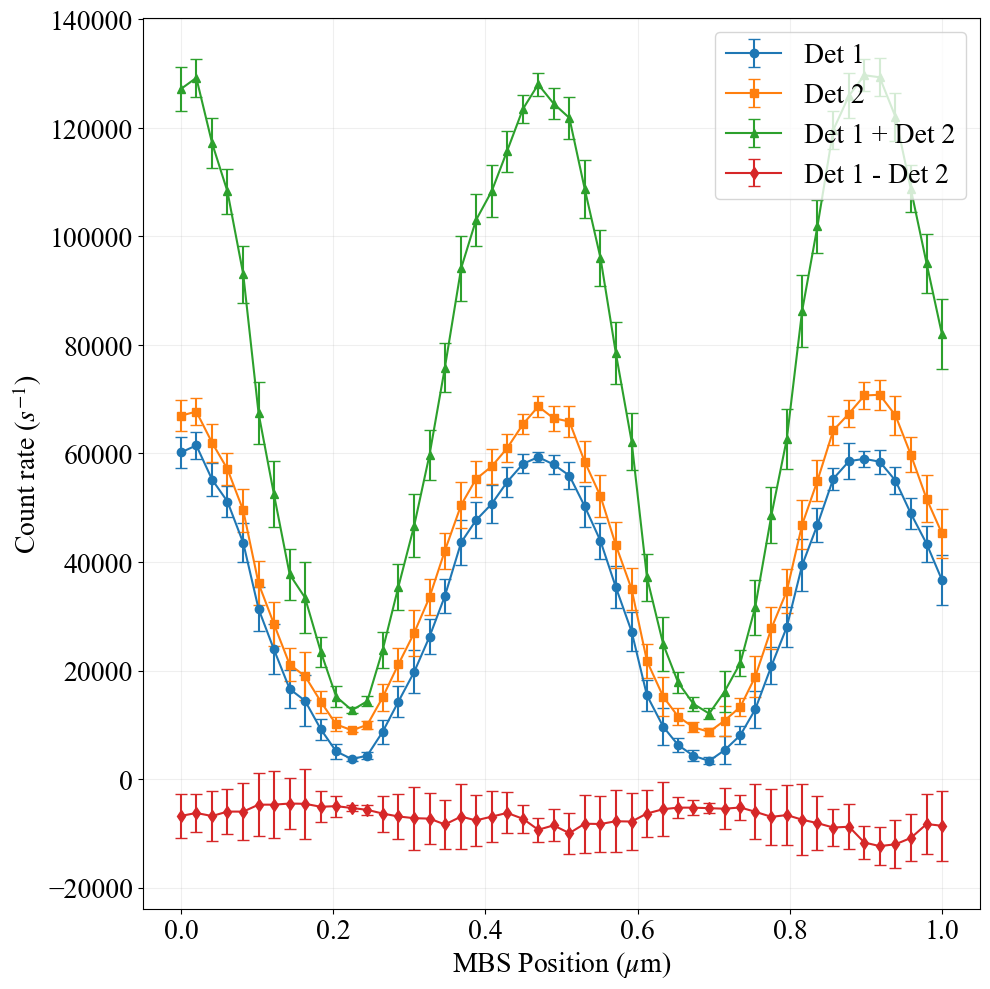

In [796]:
## plots

# Vetoed channel data
mean1_veto = veto_mean_rates[0]
mean2_veto = veto_mean_rates[1]

std1_veto = veto_std_rates[0]
std2_veto = veto_std_rates[1]

tau = 0.62   # example detection efficiency correction

mean1_veto = tau * mean1_veto
std1_veto  = tau * std1_veto


# Sum and difference
sum12_veto  = mean1_veto + mean2_veto
diff12_veto = mean1_veto - mean2_veto

sum12_veto_err  = np.sqrt(std1_veto**2 + std2_veto**2)
diff12_veto_err = np.sqrt(std1_veto**2 + std2_veto**2)

plt.figure(figsize=(10, 10))

plt.errorbar(distArr_measured, mean1_veto, yerr=std1_veto,
             fmt='o-', capsize=4, label='Det 1')

plt.errorbar(distArr_measured, mean2_veto, yerr=std2_veto,
             fmt='s-', capsize=4, label='Det 2')

plt.errorbar(distArr_measured, sum12_veto, yerr=sum12_veto_err,
             fmt='^-', capsize=4, label='Det 1 + Det 2')

plt.errorbar(distArr_measured, diff12_veto, yerr=diff12_veto_err,
             fmt='d-', capsize=4, label='Det 1 - Det 2')

plt.xlabel("MBS Position ($\\mu$m)", fontsize=20)
plt.ylabel("Count rate ($s^{-1}$)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(alpha=0.2)
plt.legend(loc='upper right', fontsize=20)
plt.tight_layout()
# plt.savefig(
#     "forThesis/trace/trace_00-100.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

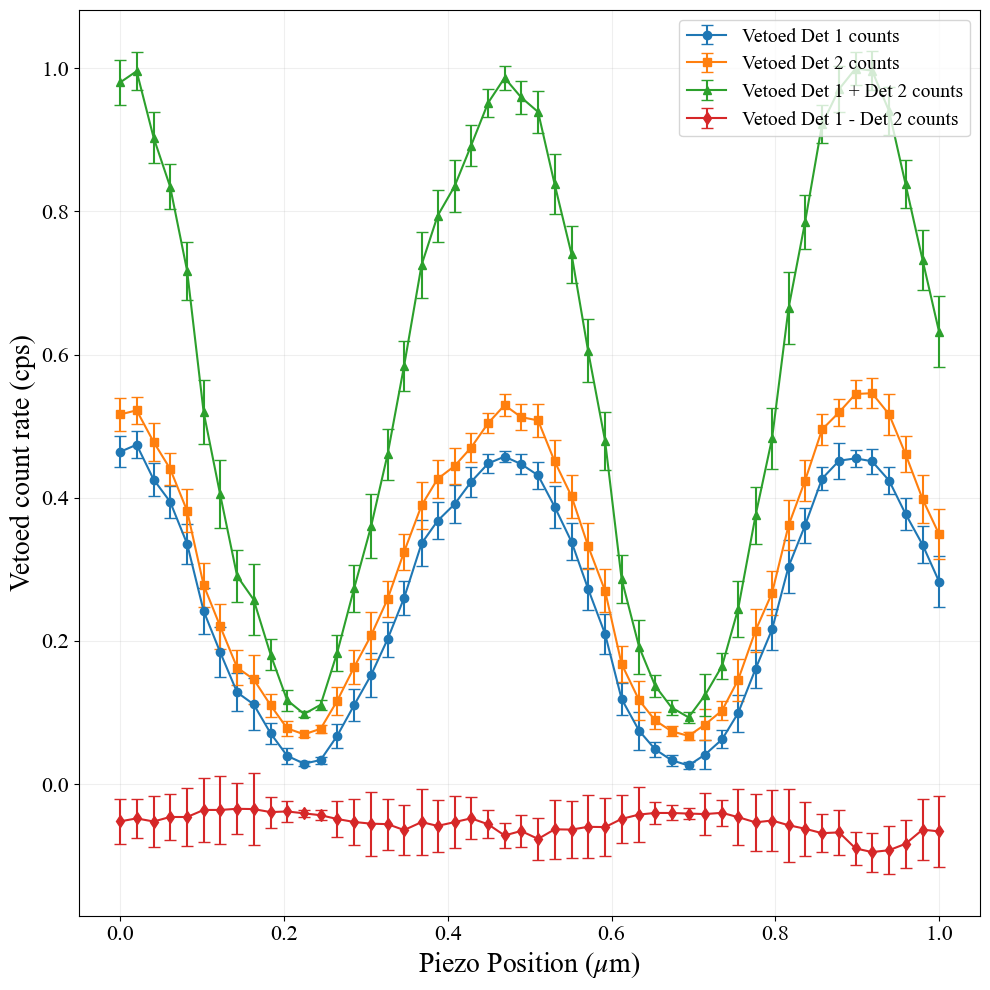

In [797]:
## peak normalised plots

# Vetoed channel data
mean1_veto = veto_mean_rates[0]
mean2_veto = veto_mean_rates[1]

std1_veto = veto_std_rates[0]
std2_veto = veto_std_rates[1]

tau = 0.62   # example detection efficiency correction

mean1_veto = tau * mean1_veto
std1_veto  = tau * std1_veto

# Sum and difference
sum12_veto  = mean1_veto + mean2_veto
diff12_veto = mean1_veto - mean2_veto

sum12_veto_err  = np.sqrt(std1_veto**2 + std2_veto**2)
diff12_veto_err = np.sqrt(std1_veto**2 + std2_veto**2)

# peak normalisation

Normfac_veto = np.max(sum12_veto)

# Normalised quantities
mean1_veto_n = mean1_veto / Normfac_veto
mean2_veto_n = mean2_veto / Normfac_veto


std1_veto_n  = std1_veto / Normfac_veto
std2_veto_n  = std2_veto / Normfac_veto

sum12_veto_n  = sum12_veto / Normfac
diff12_veto_n = diff12_veto / Normfac

sum12_err_veto_n  = sum12_err / Normfac
diff12_err_veto_n = diff12_err / Normfac


plt.figure(figsize=(10, 10))

plt.errorbar(distArr_measured, mean1_veto_n, yerr=std1_veto_n,
             fmt='o-', capsize=4, label='Vetoed Det 1 counts')

plt.errorbar(distArr_measured, mean2_veto_n, yerr=std2_veto_n,
             fmt='s-', capsize=4, label='Vetoed Det 2 counts')

plt.errorbar(distArr_measured, sum12_veto_n, yerr=sum12_err_veto_n,
             fmt='^-', capsize=4, label='Vetoed Det 1 + Det 2 counts')

plt.errorbar(distArr_measured, diff12_veto_n, yerr=diff12_err_veto_n,
             fmt='d-', capsize=4, label='Vetoed Det 1 - Det 2 counts')

plt.xlabel("Piezo Position ($\\mu$m)", fontsize=20)
plt.ylabel("Vetoed count rate (cps)", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(alpha=0.2)
plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()
plt.show()

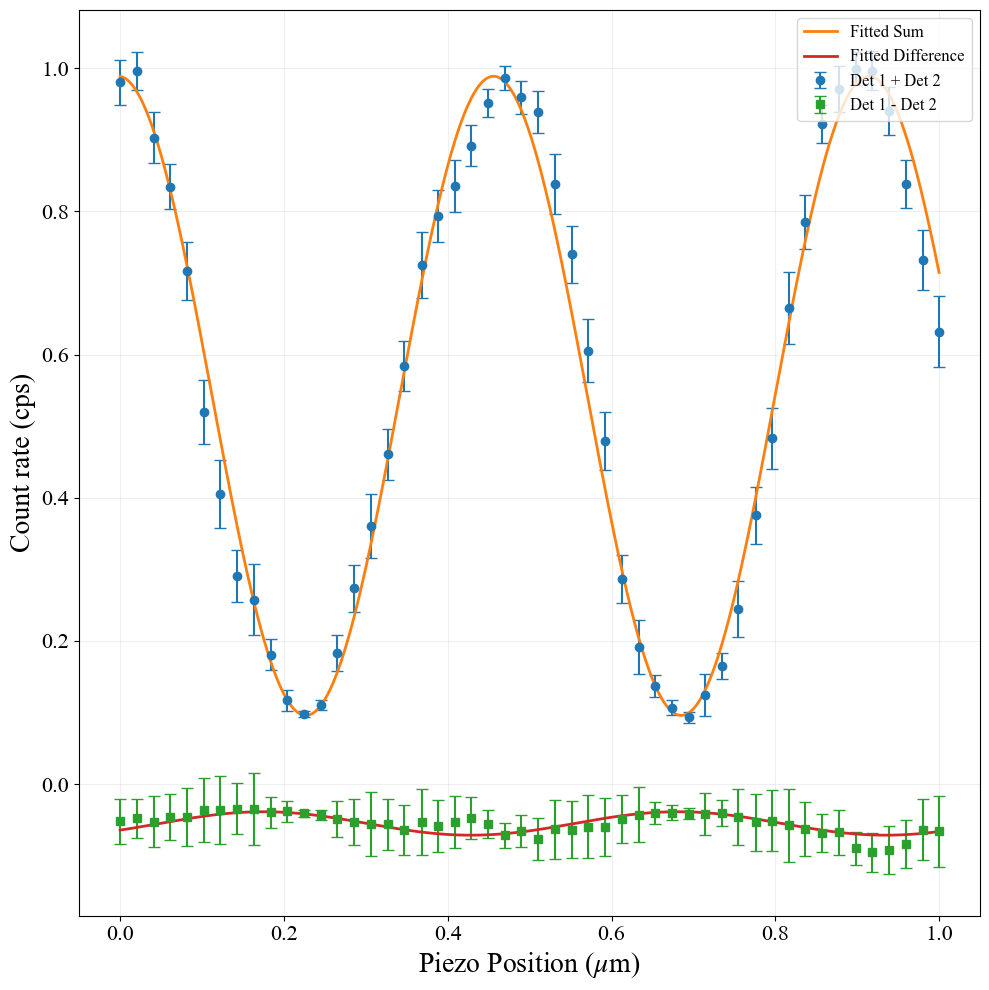

----- SUM -----
I0_sum = 0.542 ± 0.003 cps
A_sum  = 0.447 ± 0.004 cps
k_sum  = 13.712 ± 0.058 rad/μm
phi_sum = 0.032 ± 0.032 rad
Visibility_sum = 0.823

----- DIFFERENCE -----
I0_diff = -0.055 ± 0.003 cps
A_diff  = -0.016 ± 0.004 cps
k_diff  = 12.409 ± 1.250 rad/μm
phi_diff = 0.970 ± 0.566 rad
Amplitude ratio abs(A_diff / A_sum) = 0.037

Goodness of fit: SUM
Chi-square = 71.256
Degrees of freedom = 46
Reduced chi-square = 1.549
R^2 = 0.9826

Goodness of fit: DIFFERENCE
Chi-square = 4.921
Degrees of freedom = 46
Reduced chi-square = 0.107
R^2 = 0.6186


In [798]:
# Fitting

# -------------------------
# Prepare CW data
# -------------------------
x = distArr_measured

y_sum  = sum12_veto_n
y_diff = diff12_veto_n

yerr_sum  = sum12_err_veto_n
yerr_diff = diff12_err_veto_n

# -------------------------
# Initial guesses
# -------------------------
period_est = 0.46
k_guess = 2 * np.pi / period_est
phi_guess = 0

I0_sum_guess = np.mean(y_sum)
A_sum_guess  = (np.max(y_sum) - np.min(y_sum)) / 2

I0_diff_guess = np.mean(y_diff)
A_diff_guess  = (np.max(y_diff) - np.min(y_diff)) / 2

p0_sum  = [I0_sum_guess,  A_sum_guess,  k_guess, phi_guess]
p0_diff = [I0_diff_guess, A_diff_guess, k_guess, phi_guess]


# -------------------------
# Fit
# -------------------------
popt_sum, pcov_sum = curve_fit(
    fringe_model, x, y_sum,
    p0=p0_sum,
    sigma=yerr_sum,
    absolute_sigma=True,
    maxfev=10000
)

popt_diff, pcov_diff = curve_fit(
    fringe_model, x, y_diff,
    p0=p0_diff,
    sigma=yerr_diff,
    absolute_sigma=True,
    maxfev=10000
)

I0_sum_fit, A_sum_fit, k_sum_fit, phi_sum_fit = popt_sum
I0_diff_fit, A_diff_fit, k_diff_fit, phi_diff_fit = popt_diff

perr_sum  = np.sqrt(np.diag(pcov_sum))
perr_diff = np.sqrt(np.diag(pcov_diff))


# -------------------------
# Fitted curves
# -------------------------
x_fit = np.linspace(x.min(), x.max(), 1000)

y_fit_sum  = fringe_model(x_fit, *popt_sum)
y_fit_diff = fringe_model(x_fit, *popt_diff)

y_fit_sum_data  = fringe_model(x, *popt_sum)
y_fit_diff_data = fringe_model(x, *popt_diff)


# -------------------------
# Visibility / amplitude ratio
# -------------------------
I_max_sum = np.max(y_fit_sum)
I_min_sum = np.min(y_fit_sum)

visibility_sum = (I_max_sum - I_min_sum) / (I_max_sum + I_min_sum)
amp_ratio = abs(A_diff_fit / A_sum_fit)


# -------------------------
# Goodness of fit
# -------------------------
n_params = len(popt_sum)

chi2_sum, dof_sum, red_chi2_sum, r2_sum = goodness_of_fit(
    y_sum, y_fit_sum_data, yerr_sum, n_params
)

chi2_diff, dof_diff, red_chi2_diff, r2_diff = goodness_of_fit(
    y_diff, y_fit_diff_data, yerr_diff, n_params
)


# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10, 10))

plt.errorbar(
    x, y_sum, yerr=yerr_sum,
    fmt='o', capsize=4,
    label='Det 1 + Det 2'
)

plt.plot(
    x_fit, y_fit_sum,
    '-', linewidth=2,
    label='Fitted Sum'
)

plt.errorbar(
    x, y_diff, yerr=yerr_diff,
    fmt='s', capsize=4,
    label='Det 1 - Det 2'
)

plt.plot(
    x_fit, y_fit_diff,
    '-', linewidth=2,
    label='Fitted Difference'
)

plt.xlabel("Piezo Position ($\\mu$m)", fontsize=20)
plt.ylabel("Count rate (cps)", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(alpha=0.2)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()


# -------------------------
# Print results
# -------------------------
print("----- SUM -----")
print(f"I0_sum = {I0_sum_fit:.3f} ± {perr_sum[0]:.3f} cps")
print(f"A_sum  = {A_sum_fit:.3f} ± {perr_sum[1]:.3f} cps")
print(f"k_sum  = {k_sum_fit:.3f} ± {perr_sum[2]:.3f} rad/μm")
print(f"phi_sum = {phi_sum_fit:.3f} ± {perr_sum[3]:.3f} rad")
print(f"Visibility_sum = {visibility_sum:.3f}")

print("\n----- DIFFERENCE -----")
print(f"I0_diff = {I0_diff_fit:.3f} ± {perr_diff[0]:.3f} cps")
print(f"A_diff  = {A_diff_fit:.3f} ± {perr_diff[1]:.3f} cps")
print(f"k_diff  = {k_diff_fit:.3f} ± {perr_diff[2]:.3f} rad/μm")
print(f"phi_diff = {phi_diff_fit:.3f} ± {perr_diff[3]:.3f} rad")
print(f"Amplitude ratio abs(A_diff / A_sum) = {amp_ratio:.3f}")

print("\nGoodness of fit: SUM")
print(f"Chi-square = {chi2_sum:.3f}")
print(f"Degrees of freedom = {dof_sum}")
print(f"Reduced chi-square = {red_chi2_sum:.3f}")
print(f"R^2 = {r2_sum:.4f}")

print("\nGoodness of fit: DIFFERENCE")
print(f"Chi-square = {chi2_diff:.3f}")
print(f"Degrees of freedom = {dof_diff}")
print(f"Reduced chi-square = {red_chi2_diff:.3f}")
print(f"R^2 = {r2_diff:.4f}")

### saving fit sum plot

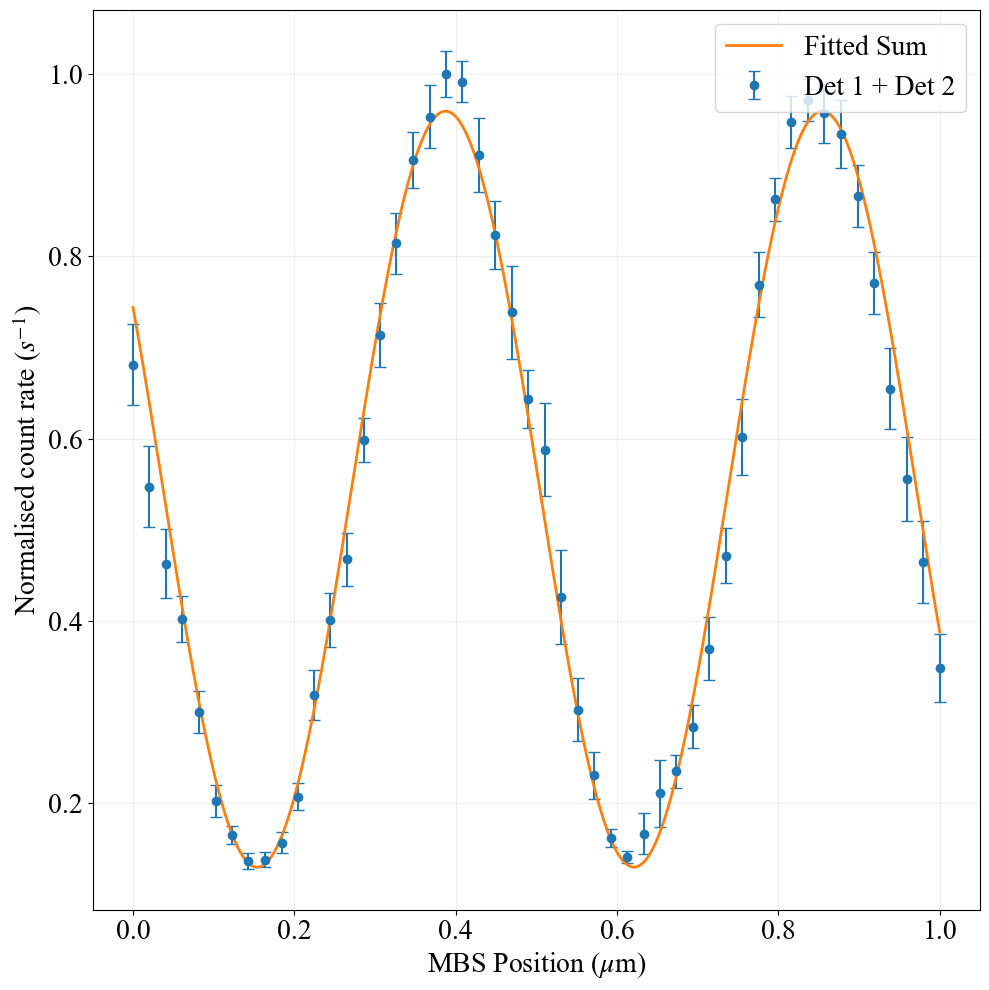

----- SUM -----
I0_sum = 0.545 ± 0.004 cps
A_sum  = 0.415 ± 0.004 cps
k_sum  = 13.458 ± 0.046 rad/μm
phi_sum = 1.069 ± 0.024 rad
Visibility_sum = 0.761

Goodness of fit: SUM
Chi-square = 54.033
Degrees of freedom = 46
Reduced chi-square = 1.175
R^2 = 0.9852


In [782]:
# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10, 10))

plt.errorbar(
    x, y_sum, yerr=yerr_sum,
    fmt='o', capsize=4,
    label='Det 1 + Det 2'
)

plt.plot(
    x_fit, y_fit_sum,
    '-', linewidth=2,
    label='Fitted Sum'
)

plt.xlabel("MBS Position ($\\mu$m)", fontsize=20)
plt.ylabel("Normalised count rate ($s^{-1}$)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(alpha=0.2)
plt.legend(fontsize=20, loc='upper right')
plt.tight_layout()
# plt.savefig(
#     "forThesis/tracefit/tracefit_00-100.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()


# -------------------------
# Print results
# -------------------------
print("----- SUM -----")
print(f"I0_sum = {I0_sum_fit:.3f} ± {perr_sum[0]:.3f} cps")
print(f"A_sum  = {A_sum_fit:.3f} ± {perr_sum[1]:.3f} cps")
print(f"k_sum  = {k_sum_fit:.3f} ± {perr_sum[2]:.3f} rad/μm")
print(f"phi_sum = {phi_sum_fit:.3f} ± {perr_sum[3]:.3f} rad")
print(f"Visibility_sum = {visibility_sum:.3f}")



print("\nGoodness of fit: SUM")
print(f"Chi-square = {chi2_sum:.3f}")
print(f"Degrees of freedom = {dof_sum}")
print(f"Reduced chi-square = {red_chi2_sum:.3f}")
print(f"R^2 = {r2_sum:.4f}")


In [654]:
# Choose one position
idist = 15

pos_dir = os.path.join(RAW_BASE, f"RawtagMountPos{idist}")
raw_npz = os.path.join(pos_dir, f"stream_tags_pos_{idist}.npz")

raw = np.load(raw_npz)

ts = raw["timestamps_ps"]
ch = raw["channel_ids"]
types = raw["event_types"] if "event_types" in raw.files and raw["event_types"].size else None

if types is not None:
    good = (types == 0)
    ts = ts[good]
    ch = ch[good]

# Before-veto counts
raw_N1 = np.sum(ch == 1)
raw_N2 = np.sum(ch == 2)
raw_N3 = np.sum(ch == 3)

keep, counts_after, ts_sorted, ch_sorted = veto_events_from_tags_pairwise_return_tags(
    ts,
    ch,
    kept_channels=(1, 2, 3),
    coincidence_window_ps=1000,
    cross_veto_pairs=((1,2), (1,3), (2,3))
)

# After-veto counts
veto_N1 = counts_after[1]
veto_N2 = counts_after[2]
veto_N3 = counts_after[3]

print("=== Before veto ===")
print(f"Ch1 = {raw_N1}")
print(f"Ch2 = {raw_N2}")
print(f"Ch3 = {raw_N3}")

print("\n=== After veto ===")
print(f"Ch1 = {veto_N1}")
print(f"Ch2 = {veto_N2}")
print(f"Ch3 = {veto_N3}")

print("\n=== Removed by veto ===")
print(f"Ch1 removed = {raw_N1 - veto_N1}")
print(f"Ch2 removed = {raw_N2 - veto_N2}")
print(f"Ch3 removed = {raw_N3 - veto_N3}")

print("\n=== Fraction removed ===")
print(f"Ch1 removed fraction = {(raw_N1 - veto_N1) / raw_N1:.3e}")
print(f"Ch2 removed fraction = {(raw_N2 - veto_N2) / raw_N2:.3e}")
print(f"Ch3 removed fraction = {(raw_N3 - veto_N3) / raw_N3:.3e}")

=== Before veto ===
Ch1 = 2638459
Ch2 = 1312695
Ch3 = 3326563

=== After veto ===
Ch1 = 2638028
Ch2 = 1312427
Ch3 = 3326080

=== Removed by veto ===
Ch1 removed = 431
Ch2 removed = 268
Ch3 removed = 483

=== Fraction removed ===
Ch1 removed fraction = 1.634e-04
Ch2 removed fraction = 2.042e-04
Ch3 removed fraction = 1.452e-04


### velocity field from raw tags data

In [655]:
meanAll = np.vstack((mean1_veto_n, mean2_veto_n))
meanAll.shape

theta_deg = AngleOfFirstWaveplate.item()
detect_eff_correction = 1.0
Vel_vec, Vel_mag = CalculateVelocities(meanAll, diff_const=I0_diff_fit*1e-6, theta = 4.0, detect_eff_correction=detect_eff_correction, exptData=True)

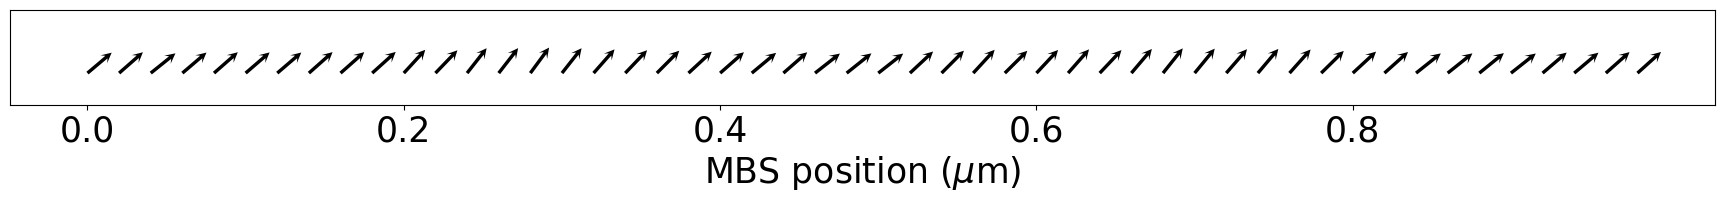

In [ ]:
Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]

N = Vx.size
x_positions = np.arange(N)          # 1D positions
y_positions = np.zeros(N)           # Put all arrows on y = 0 axis

plt.figure(figsize=(22,4))

plt.quiver(
    x_positions, y_positions,   # positions of arrows
    Vx, Vy,                     # arrow components
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.002,
    headwidth=3,
    headlength=3,
    headaxislength=2
)

plt.gca().set_aspect('equal', adjustable='box')

plt.ylim(-1, 2)

# convert x-axis tick labels from index to piezo position
step_um = 0.02

tick_positions = np.arange(0, N, 10)          # index positions: 0, 10, 20, 30, 40
tick_labels = tick_positions * step_um        # micron labels: 0.0, 0.2, 0.4, 0.6, 0.8

plt.xticks(
    tick_positions,
    [f"{x:.1f}" for x in tick_labels], fontsize = 25
)
plt.yticks([]) # want no y ticks
plt.xlabel("MBS position ($\\mu$m)", fontsize = 25)
#plt.ylabel("Vector direction")
#plt.grid(True, alpha = 0.5)
# plt.savefig(
#     "forThesis/vectors/vectors_00-100.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )

plt.show()


In [658]:
theta_deg = 4
scale = (np.sin(2 * np.radians(theta_deg)))
velocity = (mean1_veto_n - mean2_veto_n)/(scale*(mean1_veto_n + mean2_veto_n))
angle = np.degrees(np.arctan(velocity))
angle
# print(np.mean(angle))
# print(np.std(angle))

array([49.78510266, 48.76201895, 51.28231272, 49.53671472, 48.72846565,
       49.19123891, 49.40946264, 48.44026839, 48.51326525, 47.98825056,
       42.61030508, 43.92417536, 38.115438  , 37.8796868 , 36.32644347,
       38.22496301, 41.398333  , 43.67326458, 44.93903787, 47.24262696,
       48.7324145 , 50.23194252, 48.82719966, 51.85516073, 51.42902771,
       51.81449941, 46.99298758, 44.95029926, 42.62125096, 45.2360445 ,
       43.06737071, 41.45018788, 43.38804825, 40.36350954, 38.64664923,
       39.38212063, 40.96302288, 40.21084101, 41.74414166, 45.57980431,
       47.28163245, 48.15558   , 51.45028492, 51.3800854 , 50.84478611,
       51.70657152, 49.52939135, 49.83702939, 48.40660766, 48.02535208])

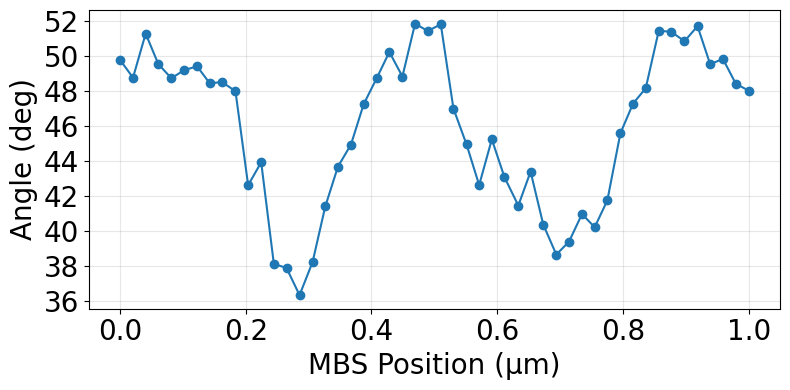

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(distArr_measured, angle, 'o-', linewidth=1.5)

# plt.axhline(np.mean(angle), color='r', linestyle='--',
#             label=f"Mean = {np.mean(angle):.2f}°")

plt.xlabel("MBS Position (μm)",fontsize=20)
plt.ylabel("Angle (deg)",fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.title("Bohmian Angle vs Position")
plt.grid(True, alpha=0.3)
#plt.legend()
plt.tight_layout()
# plt.savefig(
#     "forThesis/angles/angles_00-100.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

Discrete sum = 2500.0
Area normalisation = 1.0


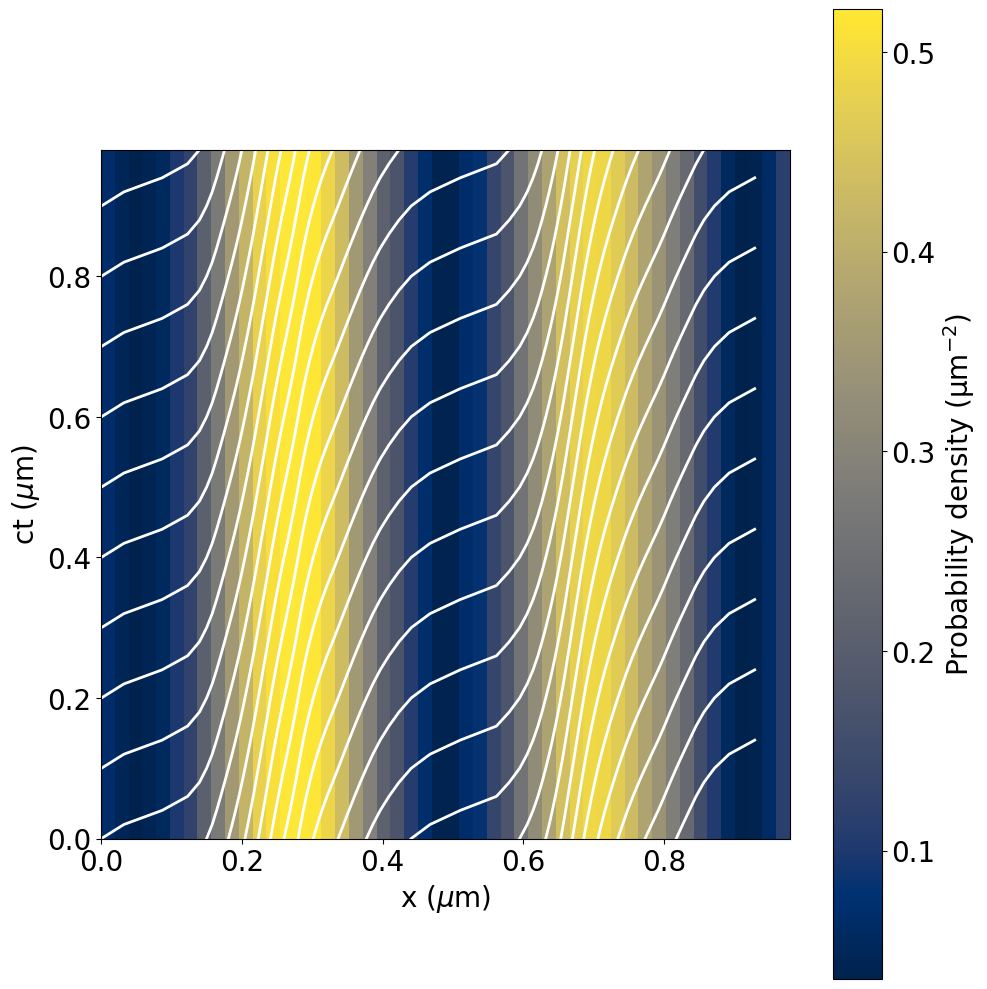

In [ ]:
Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]

N = Vx.size
n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

# probability density
dx = 0.02   # micron, physical scan spacing
dy = 0.02   # micron, artificial ct spacing chosen to match x spacing

prob_1d = mean1_veto_n + mean2_veto_n
prob_1d = np.asarray(prob_1d, dtype=float)
prob_1d = np.nan_to_num(prob_1d, nan=0.0)
prob_1d[prob_1d < 0] = 0

# stack into 2D
prob_2d = np.tile(prob_1d, (n_rows_top + n_rows_bottom, 1))

# area normalise
prob_2d /= np.sum(prob_2d) * dx * dy

print("Discrete sum =", np.sum(prob_2d))
print("Area normalisation =", np.sum(prob_2d) * dx * dy)

y_vals = np.arange(-n_rows_bottom, n_rows_top) * y_spacing

plt.figure(figsize=(10, 10))

plt.imshow(
    prob_2d,
    origin='lower',
    aspect='equal',
    cmap='cividis',
    extent=[0, N-1, y_vals[0], y_vals[-1]]
)

cbar = plt.colorbar()
cbar.set_label("Probability density (μm$^{-2}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

# trajectories
left_start_rows = np.arange(-n_rows_bottom, n_rows_top, 5)

for j0 in left_start_rows:
    xs = [0]
    ys = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    # integrate upward
    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)
        
    plt.plot(xs, ys, linewidth=2, color='white')
    #plt.scatter(xs, ys, s=5, color='white', alpha=0.6)
    

ticksforfig = np.arange(0, 1, 0.2)         # desired ticks

xticks = ticksforfig / dx                  # Convert to index positions
yticks = ticksforfig / dy

# Apply ticks
plt.xticks(xticks, [f"{ticks:.1f}" for ticks in ticksforfig], fontsize=20)
plt.yticks(yticks, [f"{ticks:.1f}" for ticks in ticksforfig], fontsize=20)

# Labels
plt.xlabel("x ($\\mu$m)", fontsize=20)
plt.ylabel("ct ($\\mu$m)", fontsize=20)    

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(0, N-1)
plt.ylim(0, N-1)
# plt.xlabel("Spatial index")
# plt.ylabel("Stacked time index")

#plt.title("Stacked Probability Density Map with Trajectories")
plt.grid(False)
plt.tight_layout()
# plt.savefig(
#     "forThesis/traj/traj_30-70.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()
        

Discrete sum = 2500.0
Area normalisation = 1.0


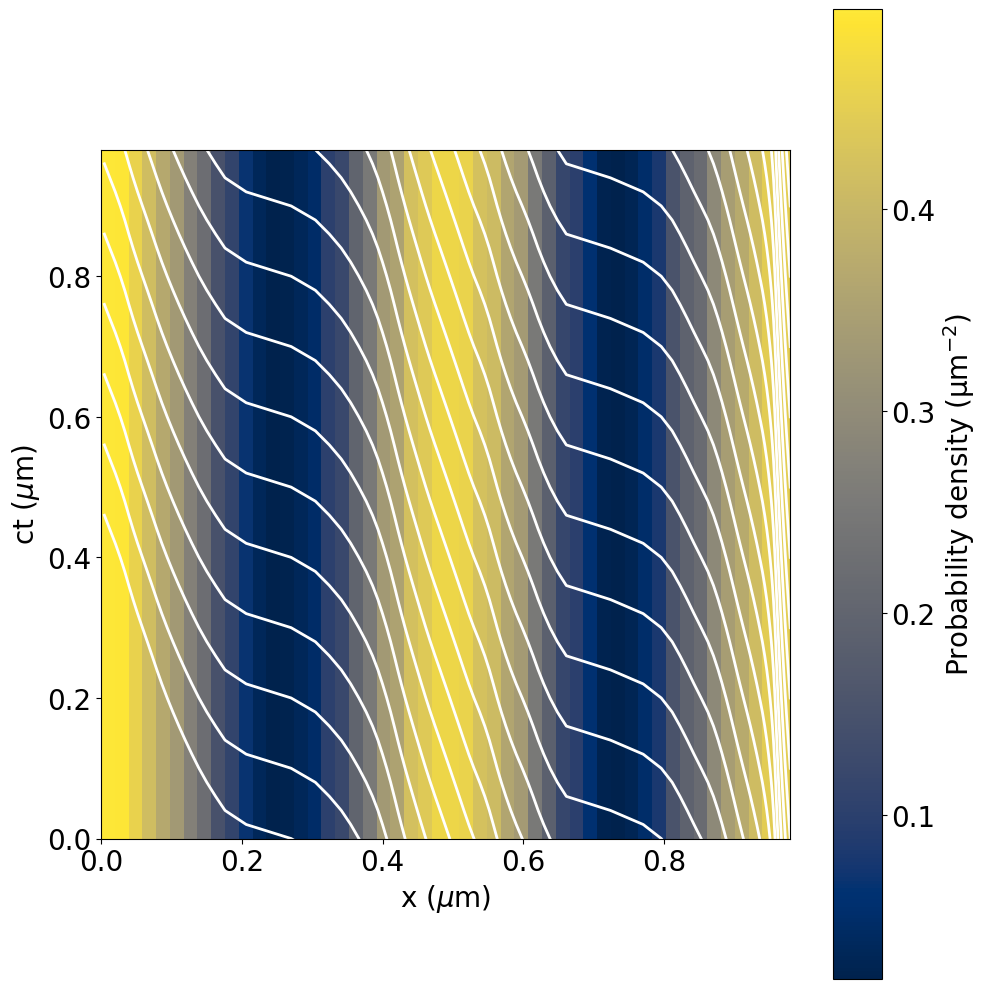

In [ ]:
Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]

N = Vx.size
n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

# probability density
dx = 0.02   # micron, physical scan spacing
dy = 0.02   # micron, artificial ct spacing chosen to match x spacing

prob_1d = mean1_n + mean2_n
prob_1d = np.asarray(prob_1d, dtype=float)
prob_1d = np.nan_to_num(prob_1d, nan=0.0)
prob_1d[prob_1d < 0] = 0

# stack into 2D
prob_2d = np.tile(prob_1d, (n_rows_top + n_rows_bottom, 1))

# area normalise
prob_2d /= np.sum(prob_2d) * dx * dy

print("Discrete sum =", np.sum(prob_2d))
print("Area normalisation =", np.sum(prob_2d) * dx * dy)

y_vals = np.arange(-n_rows_bottom, n_rows_top) * y_spacing

plt.figure(figsize=(10, 10))

plt.imshow(
    prob_2d,
    origin='lower',
    aspect='equal',
    cmap='cividis',
    extent=[0, N-1, y_vals[0], y_vals[-1]]
)

cbar = plt.colorbar()
cbar.set_label("Probability density (μm$^{-2}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

# trajectories starting from the right time axis
right_start_rows = np.arange(-n_rows_bottom, n_rows_top, 5)

for j0 in right_start_rows:
    xs = [N - 1]
    ys = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    # integrate upward, but from right to left
    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        # minus sign makes trajectories enter from the right
        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    plt.plot(xs, ys, linewidth=2, color='white')
    #plt.scatter(xs, ys, s=5, color='white', alpha=0.6)
    
ticksforfig = np.arange(0, 1, 0.2)         # desired ticks

xticks = ticksforfig / dx                  # Convert to index positions
yticks = ticksforfig / dy

# Apply ticks
plt.xticks(xticks, [f"{ticks:.1f}" for ticks in ticksforfig], fontsize=20)
plt.yticks(yticks, [f"{ticks:.1f}" for ticks in ticksforfig], fontsize=20)

# Labels
plt.xlabel("x ($\\mu$m)", fontsize=20)
plt.ylabel("ct ($\\mu$m)", fontsize=20)    

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(0, N-1)
plt.ylim(0, N-1)
# plt.xlabel("Spatial index")
# plt.ylabel("Stacked time index")

#plt.title("Stacked Probability Density Map with Trajectories")
plt.grid(False)
plt.tight_layout()
# plt.savefig(
#     "forThesis/traj/traj_70-30.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )

plt.show()
